In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

In [3]:
df = pd.read_csv('data.csv')
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [4]:
# numeric cols

data = df.drop(columns=['country']).copy()
data.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


## KNN

In [5]:
# train test split (80/20)

def train_test_split(X, y, test_size=0.2, random_state=1):
	rng = np.random.RandomState(random_state)
	idx = np.arange(X.shape[0])
	rng.shuffle(idx)
	split = int(X.shape[0] * (1 - test_size))
	train_idx, test_idx = idx[:split], idx[split:]

	return X[train_idx], X[test_idx], y[train_idx], y[test_idx]

In [6]:
# scaler

class StandardScaler:
	def fit(self, X):
		self.mean_ = X.mean(axis=0)
		self.std_ = X.std(axis=0, ddof=0)
		self.std_[self.std_ == 0] = 1
	
	def transform(self, X):
		return (X - self.mean_) / self.std_
	
	def fit_transform(self, X):
		self.fit(X)
		return self.transform(X)

In [7]:
# distance

def euclidean_distances(X_train, x_query):
	diff = X_train - x_query
	return np.sqrt(np.sum(diff**2, axis=1))

In [8]:
# KNN predict

def knn_predict_regression(X_train, y_train, X_test, k=5):
	preds = []
	
	for x in X_test:
		dists = euclidean_distances(X_train, x)
		nn_idx = np.argsort(dists)[:k]
		preds.append(np.mean(y_train[nn_idx]))
	
	return np.array(preds)

def knn_predict_classification(X_train, y_train, X_test, k=5):
	preds = []

	for x in X_test:
		dists = euclidean_distances(X_train, x)
		nn_idx = np.argsort(dists)[:k]
		votes = y_train[nn_idx]
		most_common = Counter(votes).most_common()
		preds.append(most_common[0][0])

	return np.array(preds)

### KNN regression

In [9]:
target = 'life_expec'
X = data.drop(columns=target).values
y_reg = data[target].values.astype(float)

In [10]:
# split

X_train, X_test, y_train_reg, y_test_reg = train_test_split(X, y_reg, test_size=0.25, random_state=67)

In [11]:
# scale

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
# errors

def rmse(a, b):
	return np.sqrt(np.mean((a - b) ** 2))

def mae(a, b):
	return np.mean(np.abs(a - b))

In [ ]:
# find best k by RMSE (1..15)

ks = list(range(1, 16))
rmse_vals = []
mae_vals = []

for k in ks:
	pred = knn_predict_regression(X_train_scaled, y_train_reg, X_test_scaled, k=k)
	rmse_vals.append(rmse(pred, y_test_reg))
	mae_vals.append(mae(pred, y_test_reg))

best_k = ks[int(np.argmin(rmse_vals))]
best_rmse = min(rmse_vals)
print(f"Best k by RMSE: {best_k} (RMSE={best_rmse:.3f})")

Best k by RMSE: 6 (RMSE=4.433)


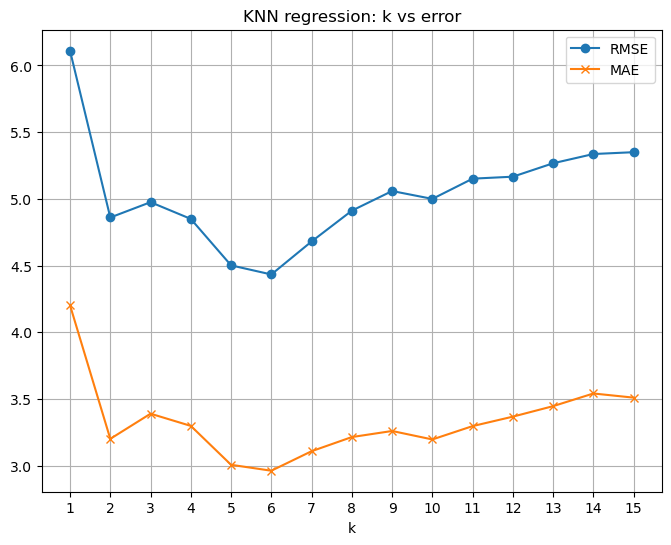

In [14]:
# plot k vs error

plt.figure(figsize=(8,6))
plt.plot(ks, rmse_vals, marker='o', label='RMSE')
plt.plot(ks, mae_vals, marker='x', label='MAE')
plt.xlabel('k')
plt.xticks(ks)
plt.title('KNN regression: k vs error')
plt.legend()
plt.grid(True)

plt.show()

In [15]:
# evaluate metrics

pred_best = knn_predict_regression(X_train_scaled, y_train_reg, X_test_scaled, k=best_k)
print("Regression metrics on test split:")

# RMSE and MAE
print(f"RMSE: {rmse(pred_best, y_test_reg):.3f}")
print(f"MAE: {mae(pred_best, y_test_reg):.3f}")

# R2 score
ss_res = np.sum((y_test_reg - pred_best)**2)
ss_tot = np.sum((y_test_reg - np.mean(y_test_reg))**2)
r2 = 1 - ss_res/ss_tot
print(f"R2 score: {r2:.3f}")

Regression metrics on test split:
RMSE: 4.433
MAE: 2.962
R2 score: 0.735


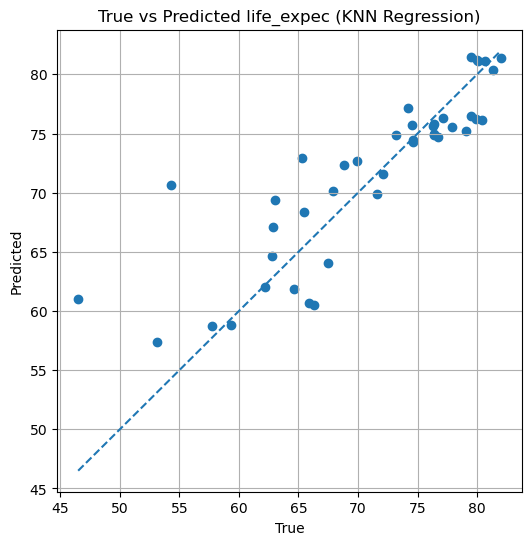

In [16]:
# true vs predicted plot

plt.figure(figsize=(6,6))
plt.scatter(y_test_reg, pred_best)
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], linestyle='--')
plt.xlabel('True')
plt.ylabel('Predicted')
plt.title('True vs Predicted life_expec (KNN Regression)')
plt.grid(True)

plt.show()

### KNN classification

In [17]:
# create binary label using median

median_le = np.median(y_reg)
y_class = (y_reg >= median_le).astype(int) # 0: low life expectancy, 1: high

In [18]:
# train test split

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X, y_class, test_size=0.25, random_state=67)

In [19]:
# scale

scaler_c = StandardScaler()
X_train_c_scaled = scaler_c.fit_transform(X_train_c)
X_test_c_scaled = scaler_c.transform(X_test_c)

In [20]:
# find best k by accuracy (1..15)

ks = list(range(1, 16))
accs = []

for k in ks:
	pred_c = knn_predict_classification(X_train_c_scaled, y_train_c, X_test_c_scaled, k=k)
	acc = (pred_c == y_test_c).mean()
	accs.append(acc)

best_k_c = ks[int(np.argmax(accs))]
best_acc = max(accs)
print(f"Classification: best k by accuracy = {best_k_c} (accuracy={best_acc:.3f})")

Classification: best k by accuracy = 3 (accuracy=0.976)


#### Evaluate metrics

In [40]:
# accuracy

def accuracy(y_true, y_pred):
	return (y_true == y_pred).mean()

In [41]:
# confusion matrix

def confusion_matrix(y_true, y_pred):
	tp = np.sum((y_true == 1) & (y_pred == 1))
	fp = np.sum((y_true == 0) & (y_pred == 1))
	tn = np.sum((y_true == 0) & (y_pred == 0))
	fn = np.sum((y_true == 1) & (y_pred == 0))
	return np.array([[tn, fp], [fn, tp]])

In [42]:
# precision, recall, f1 score

def f1(y_true, y_pred, pos_class):
	tp = np.sum((y_true == pos_class) & (y_pred == pos_class))
	fp = np.sum((y_true != pos_class) & (y_pred == pos_class))
	fn = np.sum((y_true == pos_class) & (y_pred != pos_class))

	precision = tp / (tp + fp) if (tp + fp) != 0 else 0
	recall = tp / (tp + fn) if (tp + fn) != 0 else 0
	f1 = 2 * precision * recall / (precision + recall) if (precision + recall) != 0 else 0

	return precision, recall, f1

In [43]:
# overall classification report

def classification_report(y_true, y_pred):
	cm = confusion_matrix(y_true, y_pred)
	tn, fp = cm[0]
	fn, tp = cm[1]

	print("Confusion Matrix:")
	print(cm)
	print()

	prec0, rec0, f10 = f1(y_true, y_pred, pos_class=0)
	prec1, rec1, f11 = f1(y_true, y_pred, pos_class=1)

	print("Class 0:")
	print(f"Precision: {prec0:.3f}")
	print(f"Recall: {rec0:.3f}")
	print(f"F1 score: {f10:.3f}\n")

	print("Class 1:")
	print(f"Precision: {prec1:.3f}")
	print(f"Recall: {rec1:.3f}")
	print(f"F1 score: {f11:.3f}\n")

	acc = accuracy(y_true, y_pred)
	print(f"Overall accuracy: {acc:.3f}")

In [22]:
pred_c_best = knn_predict_classification(X_train_c_scaled, y_train_c, X_test_c_scaled, k=best_k_c)
classification_report(y_test_c, pred_c_best)

Confusion Matrix:
[[19  1]
 [ 0 22]]

Class 0:
Precision: 1.000
Recall: 0.950
F1 score: 0.974

Class 1:
Precision: 0.957
Recall: 1.000
F1 score: 0.978

Overall accuracy: 0.976


## K-Means Clustering

In [23]:
X_orig = data.values.astype(float)

In [24]:
# scaler

class SimpleScaler:
	def fit(self, X):
		X = np.asarray(X)
		self.mean_ = X.mean(axis=0)
		self.std_ = X.std(axis=0, ddof=0)
		self.std_[self.std_ == 0] = 1

	def transform(self, X):
		return (X - self.mean_) / self.std_
	
	def fit_transform(self, X):
		self.fit(X)
		return self.transform(X)
	
	def inverse_transform(self, Xs):
		return Xs * self.std_ + self.mean_

In [25]:
# distances

def pairwise_squared_distances(a, b):
	a = np.asarray(a)
	b = np.asarray(b)

	aa = (a ** 2).sum(axis=1)[:, None]
	bb = (b ** 2).sum(axis=1)[None, :]
	ab = a.dot(b.T)

	return aa + bb - 2*ab

### K-Means implementation

In [26]:
# helper functions

def init_centroids(X, k, random_state=None, method='kmeans++'):
	rng = np.random.RandomState(random_state)
	n = X.shape[0]

	if method == 'random':
		idx = rng.choice(n, size=k, replace=False)
		return X[idx].copy()
	
	centers = []
	idx0 = rng.randint(0, n)
	centers.append(X[idx0].copy())

	for _ in range(1, k):
		d2 = np.min(pairwise_squared_distances(X, np.vstack(centers)), axis=1)
		probs = d2 / d2.sum()
		r = rng.rand()
		cum = np.cumsum(probs)
		next_idx = np.searchsorted(cum, r)
		centers.append(X[next_idx].copy())

	return np.vstack(centers)

def assign_clusters(X, centers):
	d2 = pairwise_squared_distances(X, centers)
	labels = np.argmin(d2, axis=1)
	inertia = np.sum(np.min(d2, axis=1))
	return labels, inertia

def update_centers(X, labels, k, random_state=None):
	n_features = X.shape[1]
	centers = np.zeros((k, n_features))
	rng = np.random.RandomState(random_state)

	for i in range(k):
		members = X[labels == i]
		if len(members) == 0: centers[i] = X[rng.randint(0, X.shape[0])]
		else: centers[i] = members.mean(axis=0)
	
	return centers

In [27]:
# K-Means

def kmeans(X, k, max_iter=300, tol=1e-4, random_state=None, init_method='kmeans++'):
	X = np.asarray(X)
	centers = init_centroids(X, k, random_state=random_state, method=init_method)

	for i in range(1, max_iter+1):
		labels, inertia = assign_clusters(X, centers)
		new_centers = update_centers(X, labels, k, random_state=random_state)
		max_shift = np.sqrt(((centers - new_centers)**2).sum(axis=1)).max()
		centers = new_centers
		if max_shift <= tol: break
	
	labels, inertia = assign_clusters(X, centers)
	return {'centers': centers, 'labels': labels, 'inertia': float(inertia), 'n_iter': i}

In [28]:
# initialize scaler

scaler = SimpleScaler()
X = scaler.fit_transform(X_orig)

In [29]:
# run K-Means for k = 1..8

ks = list(range(1, 9))
inertias = []
results = {}

for k in ks:
	res = kmeans(X, k, random_state=67, init_method='kmeans++')
	inertias.append(res['inertia'])
	results[k] = res

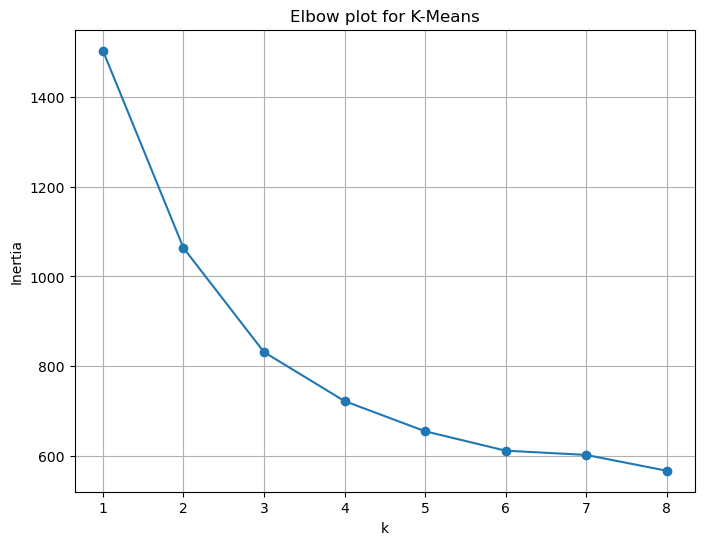

In [30]:
# elbow plot

plt.figure(figsize=(8,6))
plt.plot(ks, inertias, marker='o')
plt.xlabel('k')
plt.xticks(ks)
plt.ylabel('Inertia')
plt.title('Elbow plot for K-Means')
plt.grid(True)
plt.show()

In [31]:
# print k and inertia

print(" k -> inertia")
for k, s in zip(ks, inertias):
	print(f"{k:2d} -> {s:.3f}")

 k -> inertia
 1 -> 1503.000
 2 -> 1063.483
 3 -> 831.424
 4 -> 722.300
 5 -> 655.030
 6 -> 611.805
 7 -> 602.297
 8 -> 567.071


In [32]:
# choose k

chosen_k = 3
res = results[chosen_k]
labels = res['labels']
centers_scaled = res['centers']
centers_orig = scaler.inverse_transform(centers_scaled)

In [33]:
# cluster sizes

unique, counts = np.unique(labels, return_counts=True)
cluster_sizes = dict(zip(map(int, unique), map(int, counts)))

In [34]:
# display centers as df

centers = pd.DataFrame(centers_orig, columns=data.columns)
centers.index.name = 'cluster'
print(f"Chosen k: {chosen_k}")
print(f"Cluster sizes: {cluster_sizes}")

Chosen k: 3
Cluster sizes: {0: 47, 1: 36, 2: 84}


In [35]:
centers.round(4)

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
cluster,,,,,,,,,
0,92.9617,29.1513,6.3885,42.3234,3942.4043,12.0197,59.1872,5.0081,1922.3830
1,5.0000,58.7389,8.8078,51.4917,45672.2222,2.6712,80.1278,1.7528,42494.4444
2,21.9274,40.2439,6.2010,47.4734,12305.5952,7.6009,72.8143,2.3075,6486.4524
